# Fellgett's Advantage and Tikhonov-Net Reconstruction

This notebook implements the reconstructions presented in section 4.3 of [Hyperspectral LSFM with DMD-only shaping and neural
network reconstruction](https://hal.science/hal-04824372/document), and reproduces Fig.3 from the same. 

To illustrate Fellgett's advantage, hyperspectral cubes are reconstructed (in the least squares sense): $$\bm F_\lambda = \bm H^\dagger \bm M_\lambda$$ from raw measurements acquired using pushbroom patterns, and then compared to those reconstruced from raw measurements acquired using Hadamard patterns. 

Two further methods of reconstruction - Tikhonov regularisation and Tikhonov-Net - are also implemented using the Hadamard acquisitions, and three methods of reconstruction compared. 



The raw measurement data coming from both acquisition methods, as well as the experimental measurement patterns must be preprocessed - this preprocessed data can be obtained by downloading the raw data from the PILOT warehouse [here](https://pilot-warehouse.creatis.insa-lyon.fr/#collection/63caa9497bef31845d991351/folder/63caaa937bef31845d991353) and running the script *main_preprocess_Fellgett.py*,  or by downloading the preprocessed measurements directly ([here](https://pilot-warehouse.creatis.insa-lyon.fr/#collection/63caa9497bef31845d991351/folder/642d24900386da274769abdd)).

In [13]:
import collections
collections.Callable = collections.abc.Callable

fig_folder = './figure/'

from pathlib import Path
from spyrit.misc.disp import add_colorbar, noaxis
import matplotlib.pyplot as plt
import numpy as np
import torch
from spyrit.core.meas  import Linear
from spyrit.core.recon import PinvNet
from spyrit.core.nnet import Unet, Identity
from spyrit.core.train import load_net
import torch.nn as nn
from typing import OrderedDict
from spyrit.core.prep import Rerange, UnsplitRescale, UnsplitRescaleEstim
from spyrit.core.noise import Poisson
from spyrit.core.recon import TikhoNet
from spyrit.core.meas import LinearSplit  

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Choose to save or display
save_rec = True
save_fig = True
ext_fig = 'pdf'
dpi_fig = 600


# paths to data
data_folder = './data/2023_03_07_mRFP_DsRed_can_vs_had/'
mat_folder = '/Reconstruction/Mat_rc/'
prep_folder = '/Preprocess/'

# experimental parameters

nbin = 20*4
mudark = 105.0
sigdark = 5.0
gain = 2.6

M = 64
N = 512

# reconstruction constants
div = 1.5
alpha = 50
channel = 10, 55, 100       # to be plotted
Nl, Nh, Nc = 512, 64, 1280  # shape of preprocessed data
 
# Spectral binning **around** the central channel. The preprocessed data were binned 
# spectrally by a factor of two. Choosing c_step = 5 leads to spectral bins with 
# 2*(2*5) channels.

c_step = 5
lambda_central_list = 510, 551, 594  # Central channel in nanometer
lambda_all = np.linspace(500, 608, Nc)



## Hadamard Reconstruction

### Set up

In [14]:

Run = 'RUN0004' 

# load experimentally measured motifs
H_exp = np.load(Path(data_folder + mat_folder) / f'hadamard_matrix_{M}_{N}.npy')
H_exp /= H_exp[0,16:500].mean()
   
# Load prep data
filename = f'{Run}_Had_{Nl}_{Nh}_{Nc}_pos.npy'
prep_pos = np.load(Path(data_folder+prep_folder) / filename)

filename = f'{Run}_Had_{Nl}_{Nh}_{Nc}_neg.npy'
prep_neg =  np.load(Path(data_folder+prep_folder) / filename)

# spectral dimension comes first
prep_pos = np.moveaxis(prep_pos, -1, 0)
prep_neg = np.moveaxis(prep_neg, -1, 0)

# param #2
y = prep_pos - prep_neg #/np.expand_dims(prep_pos[:,:,0], axis=2)
y = torch.from_numpy(y)

print(f'Loaded: {filename[:-8]}')
print(f'Pos data: range={prep_pos.max() - prep_pos.min()} counts; mean={prep_pos.mean()} counts')  

y = y.to(device)
y = y.view(-1,1,N,M)

Loaded: RUN0004_Had_512_64_1280
Pos data: range=4668.0 counts; mean=263072.74484562874 counts


### Direct Reconstruction (pseudoinverse)

reconstructing spectral bin from channels: 113--123
reconstructing spectral bin from channels: 599--609
reconstructing spectral bin from channels: 1108--1118


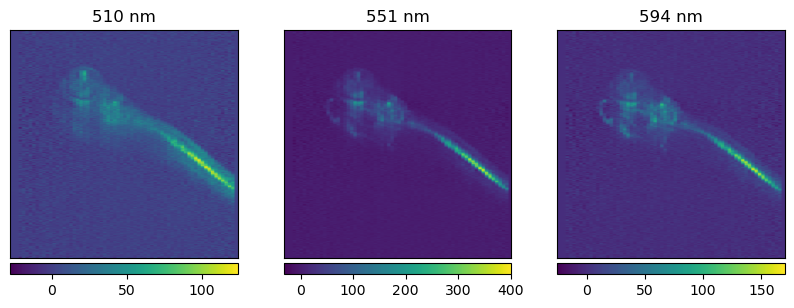

In [15]:
# create measurement operator and reconstruction network
linop = Linear(torch.from_numpy(H_exp), meas_shape = (1,512), device=device) 
recon = PinvNet(linop, store_H_pinv=True, device=device)

# init output
rec_had = np.zeros((len(lambda_central_list), N, N))

for i_lambda, lambda_central in enumerate(lambda_central_list):
    with torch.no_grad():
        c_central = np.argmin((lambda_all-lambda_central)**2) # Central channel
        m = y[c_central-c_step:c_central+c_step].sum(0, keepdim=True).to(device, torch.float32)
        print(f'reconstructing spectral bin from channels: {c_central-c_step}--{c_central+c_step}')
        rec_gpu = recon.reconstruct_pinv(m)
        rec = rec_gpu.cpu().detach().numpy().squeeze()
        rec = np.moveaxis(rec, 0, -1) # spectral channel is now the last axis
        rec = np.flip(rec,0)
        rec = np.fliplr(rec)
        rec = np.rot90(rec,-1)
        rec_had[i_lambda] = rec
    
    if save_rec:
        save_folder = 'Reconstruction/hypercube'  
        Path(data_folder+save_folder).mkdir(parents=True, exist_ok=True)
            
        save_filename = f'had_{lambda_central}_{N}x{N}.npy'
        np.save(Path(data_folder+save_folder) / save_filename, rec)

            
# Plot
fig, axs = plt.subplots(1, 3, figsize=(10,10))
for i_lambda, lambda_central in enumerate(lambda_central_list):
    im = axs[i_lambda].imshow(rec_had[i_lambda])
    axs[i_lambda].set_title(f'{lambda_central} nm')
    add_colorbar(im, 'bottom')
        
    noaxis(axs)
        
    if save_fig:
        save_filename = f'had_{lambda_central}_{N}x{N}.{ext_fig}'
        plt.savefig(Path(data_folder+save_folder)/save_filename, bbox_inches='tight', dpi=dpi_fig)
    

### Tikhonov 


#### Load Prep Data

In [16]:
# load prep data
Run = 'RUN0004' 

filename = f'{Run}_Had_{Nl}_{Nh}_{Nc}_pos.npy'
prep_pos = np.load(Path(data_folder+prep_folder) / filename)

filename = f'{Run}_Had_{Nl}_{Nh}_{Nc}_neg.npy'
prep_neg =  np.load(Path(data_folder+prep_folder) / filename)

# move spectral dimension to position 0
prep_pos = np.moveaxis(prep_pos, -1, 0)
prep_neg = np.moveaxis(prep_neg, -1, 0)

# spectral binning of both pos/neg for a few central channels
prep_pos = torch.from_numpy(prep_pos)
prep_neg = torch.from_numpy(prep_neg)

y_pos = torch.empty((len(lambda_central_list),N,M))
y_neg = torch.empty((len(lambda_central_list),N,M))

for i_lambda, lambda_central in enumerate(lambda_central_list):
    with torch.no_grad():
        c_central = np.argmin((lambda_all-lambda_central)**2) # Central channel
        
        y_pos[i_lambda] = prep_pos[c_central-c_step:c_central+c_step].sum(0, keepdim=True)
        y_neg[i_lambda] = prep_neg[c_central-c_step:c_central+c_step].sum(0, keepdim=True)
        
# param #2
background  = (2**15-1)*nbin
y_pos = y_pos - background
y_neg = y_neg - background

y = torch.empty((len(lambda_central_list), N, 2*M))
y[:,:,::2]  = y_pos #/np.expand_dims(prep_pos[:,:,0], axis=2)
y[:,:,1::2] = y_neg #/np.expand_dims(prep_pos[:,:,0], axis=2)
y = y.to(device)
y = y.view(-1,1,N,2*M) 

print(f'Loaded: {filename[:-8]}')
print(f'Pos data: shape = {prep_pos.shape}, range = {prep_pos.max() } to { prep_pos.min()}')  
print(f'Neg data: shape = {prep_neg.shape}, range = {prep_neg.max() } to { prep_neg.min()} ')  
print(f'Split data: shape = {y.shape}, range = {y.max() } to { y.min()}')  
print(f'Hadamards: shape = {H_exp.shape}, range = {H_exp.max()} to {H_exp.min()}')  

Loaded: RUN0004_Had_512_64_1280
Pos data: shape = torch.Size([1280, 512, 64]), range = 267451.0 to 262783.0
Neg data: shape = torch.Size([1280, 512, 64]), range = 267750.0 to 262786.0 
Split data: shape = torch.Size([3, 1, 512, 128]), range = 21449.0 to 7548.0
Hadamards: shape = (64, 512), range = 1.3210699360626104 to -1.1338468732493794


#### Load network and covariance matrix:

In [17]:
stat_folder = './stat/'
cov_file   = f'Cov_1_{N}x{N}.npy'
img_cov = np.load(Path(stat_folder) / cov_file)
img_cov = torch.from_numpy(img_cov).to(device)

# Read in network
net_prefix = f'tikho-net_unet_imagenet_ph_50'
net_suffix = 'N_512_M_128_epo_20_lr_0.001_sss_10_sdr_0.5_bs_20_reg_1e-07'
model_title = './model/' + net_prefix + '_exp_' + net_suffix + '.pth'

In [18]:
# create the measurement operator
noise = Poisson(alpha)
H = torch.from_numpy(H_exp)
linop = LinearSplit(H, meas_shape=(1, N),  noise_model=noise, device=device)

# Create reconstruction network
z = (y[..., ::2] + y[..., 1::2])
mu = torch.mean(z, dim=-1, keepdim=True)
alpha =  ((2 / N) * (mu - 2 * mudark) / gain).to(device)
alpha = torch.amax(alpha, -2, keepdim=True)

norm = alpha*gain
sigma =  (gain * (z - 2 * nbin * mudark)+ 2 * nbin * sigdark**2)*4
cov_meas = sigma.to(device) / norm**2
cov_meas = torch.diag_embed(cov_meas)

prep = UnsplitRescale(norm)
recnet = TikhoNet(acqu=linop, prep=prep, sigma=img_cov/div, denoi=Identity(), device=device)
recnet.eval()

TikhoNet(
  (acqu_modules): Sequential(
    (acqu): LinearSplit(
      (noise_model): Poisson()
    )
  )
  (recon_modules): Sequential(
    (prep): UnsplitRescale()
    (tikho): Tikhonov(
      (meas_op): LinearSplit(
        (noise_model): Poisson()
      )
    )
    (denoi): Identity()
  )
)

#### Reconstruct

[ 82.25812 109.89263  83.77258]


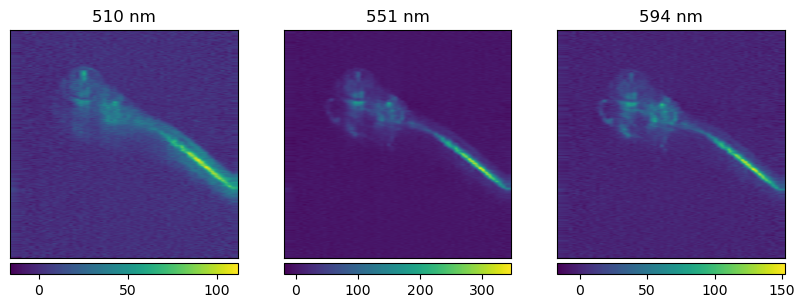

In [19]:
# Reconstruct

H_ones = (torch.from_numpy(H_exp)).sum(dim=-1).to(device)
with torch.no_grad():   

    m = recnet.prep(y) # unsplit and rescale
    m = (2*m - H_ones).to(m.dtype)

    x_hat = recnet.tikho(m,cov_meas) # tikhonov reconstruction
    x_hat = x_hat.squeeze()
    x_hat = x_hat.view(x_hat.shape[0], 1, N, N)
    

    rec_gpu = (x_hat+1)/2*norm  

rec_ticko = rec_gpu.cpu().detach().numpy().squeeze()
rec_ticko = np.fliplr(rec_ticko)


beta = norm.cpu().detach().numpy().squeeze()
print(beta)

save_rec = True
save_fig = True

fig, axs = plt.subplots(1, 3, figsize=(10,10))
for i_lambda, lambda_central in enumerate(lambda_central_list):        
    
    im = axs[i_lambda].imshow(rec_ticko[i_lambda])
    axs[i_lambda].set_title(f'{lambda_central} nm')
    add_colorbar(im, 'bottom')        
    noaxis(axs)
    
    if save_fig:
        save_filename = f'had_tikhonov_{lambda_central}_{N}x{N}.{ext_fig}'
        plt.savefig(Path(data_folder+prep_folder)/save_filename, bbox_inches='tight', dpi=dpi_fig)
        
    if save_rec:
        save_folder = '/Reconstruction/hypercube'  
        Path(data_folder+save_folder).mkdir(parents=True, exist_ok=True)
            
        save_filename = f'had_tikhonov_{lambda_central}_{N}x{N}.npy'
        np.save(Path(data_folder+save_folder) / save_filename, rec_ticko[i_lambda])

### Tikhonov and Unet

#### Reconstruct

Model Loaded: ./model/tikho-net_unet_imagenet_ph_50_exp_N_512_M_128_epo_20_lr_0.001_sss_10_sdr_0.5_bs_20_reg_1e-07.pth
[ 82.25812 109.89263  83.77258]


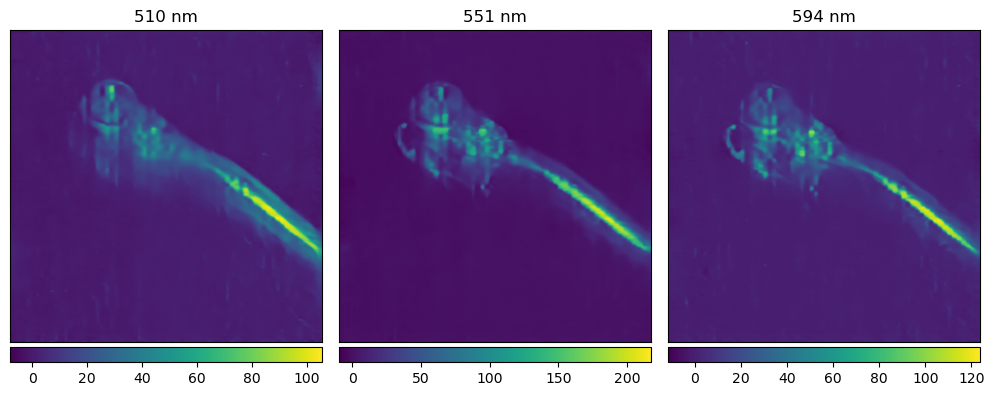

In [20]:
# create the denoiser network: rerange Unet() rerange, and load with weights from pretrained model
rerange = Rerange((0, 1), (-1, 1))
denoiser = OrderedDict({"rerange": rerange,"denoi": Unet(), "rerange_inv": rerange.inverse()})
denoiser = nn.Sequential(denoiser)
load_net(model_title, denoiser, device, False)

recnet = TikhoNet(acqu=linop, prep=prep, sigma=img_cov/div, denoi=denoiser, device=device)
recnet.eval()

with torch.no_grad():   

    m = recnet.prep(y) # unsplit and rescale
  #  m = (2*m - H_ones).to(m.dtype)

    x_hat = recnet.tikho(m,cov_meas) # tikhonov reconstruction
    x_hat = x_hat.squeeze()
    x_hat = x_hat.view(x_hat.shape[0], 1, N, N)
    
    
    x_tilde = recnet.denoi(x_hat) # denoise with Unet

    rec_gpu = x_tilde*norm #(x_tilde+1)/2*norm  
    
del recnet

rec_ticko = rec_gpu.cpu().detach().numpy().squeeze()
rec_ticko = np.fliplr(rec_ticko)


beta = norm.cpu().detach().numpy().squeeze()
print(beta)
                


fig, axs = plt.subplots(1, 3, figsize=(10, 4))

for i, lam in enumerate(lambda_central_list):
    im = axs[i].imshow(rec_ticko[i])
    axs[i].set_title(f"{lam} nm")

    add_colorbar(im, 'bottom')
    noaxis(axs[i])

plt.tight_layout()

if save_fig:
    filename = f"had_tikhonet_all_{N}x{N}.{ext_fig}"
    plt.savefig(Path(data_folder + '/Reconstruction/hypercube') / filename,
                bbox_inches='tight', dpi=dpi_fig)

if save_rec:
    rec_path = Path(data_folder + '/Reconstruction/hypercube')
    rec_path.mkdir(parents=True, exist_ok=True)

    for i, lam in enumerate(lambda_central_list):
        filename = f"had_tikhonet_{lam}_{N}x{N}.npy"
        np.save(rec_path / filename, rec_ticko[i])

plt.show()

## Pushbroom Reconstruction

### Set up

In [21]:
Run_can = 'RUN0006' 
Run_dark = 'RUN0003'  

# load motifs
H_exp = np.load(Path(data_folder + mat_folder) / f'canonical_diff_matrix_{M}_{N}.npy')

# Load prep data
filename = f'{Run_can}_Can_{Nl}_{Nh}_{Nc}_can.npy'
prep_can = np.load(Path(data_folder+prep_folder) / filename)

filename = f'{Run_dark}_Can_{Nl}_{Nh}_{Nc}_dark.npy'
prep_dark = np.load(Path(data_folder+prep_folder) / filename)

# The mean of the dark stack is substracted
prep_diff = prep_can - prep_dark.mean(1,keepdims=True)
prep_diff = np.moveaxis(prep_diff, -1, 0)
y = torch.from_numpy(prep_diff)

print(f'Loaded: {filename[:-8]}')
print(f'Pos data: range={prep_diff.max() - prep_diff.min()} counts; mean={prep_diff.mean()} counts')  

y = y.to(device)
y = y.view(-1,1,N,M) 

linop = Linear(torch.from_numpy(H_exp), meas_shape = (1,512), device=device)
recon = PinvNet(linop, store_H_pinv=True, device=device)

Loaded: RUN0003_Can_512_64_1280_
Pos data: range=18385.171875 counts; mean=7.906135869026184 counts


### Reconstruct

reconstructing spectral bin from channels: 113--123
reconstructing spectral bin from channels: 599--609
reconstructing spectral bin from channels: 1108--1118


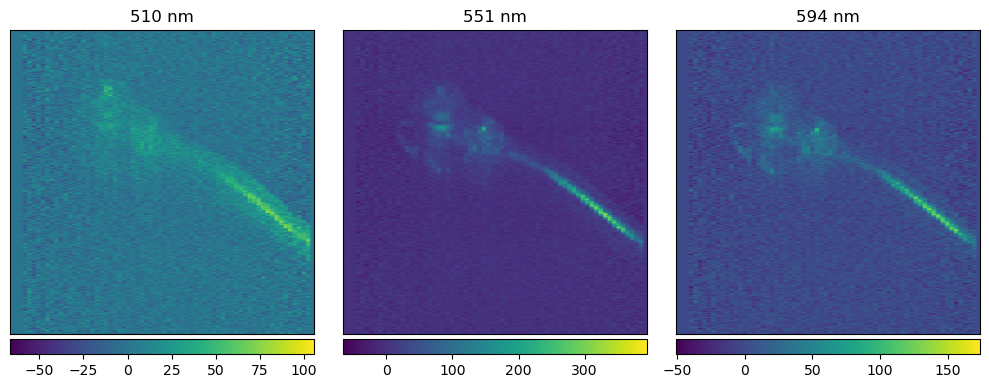

In [22]:
# init output
rec_can = np.zeros((len(lambda_central_list), N, N))

# Reconstruct all spectral bins
for i_lambda, lambda_central in enumerate(lambda_central_list):
    
    with torch.no_grad():
        c_central = np.argmin((lambda_all-lambda_central)**2) # Central channel
        
        m = y[c_central-c_step:c_central+c_step].sum(0, keepdim=True).to(device, torch.float32)
        print(f'reconstructing spectral bin from channels: {c_central-c_step}--{c_central+c_step}')
        rec_gpu = recon.reconstruct_pinv(m)
        rec = rec_gpu.cpu().detach().numpy().squeeze()
                    
        rec = np.moveaxis(rec, 0, -1) # spectral channel is now the last axis
        rec = np.flip(rec,0)
        rec = np.fliplr(rec)
        rec = np.rot90(rec,-1)
        rec_can[i_lambda] = rec
        
        if save_rec:
            save_folder = 'Reconstruction/hypercube'  
            Path(data_folder+save_folder).mkdir(parents=True, exist_ok=True)
            
            save_filename = f'can_{lambda_central}_{N}x{N}.npy'
            np.save(Path(data_folder+save_folder) / save_filename, rec)

fig, axs = plt.subplots(1, 3, figsize=(10,10))
for i_lambda, lambda_central in enumerate(lambda_central_list):        
    
    im = axs[i_lambda].imshow(rec_can[i_lambda])
    axs[i_lambda].set_title(f'{lambda_central} nm')
    add_colorbar(im, 'bottom')        
    noaxis(axs)

plt.tight_layout()

if save_fig:
    save_filename = f'can_{lambda_central}_{N}x{N}.{ext_fig}'
    plt.savefig(Path(data_folder+save_folder)/save_filename, bbox_inches='tight', dpi=dpi_fig)

plt.show()

## Visualisation

In [23]:

def psnr(image, x, y, plot=True):
    """Calculates the Peak Signal-to-Noise Ratio (PSNR) of an image.

    Args:
        image: The input image.
        x: A tuple specifying the starting and ending row indices of the background.
        y: A tuple specifying the starting and ending column indices of the background.

    Returns:
        The calculated PSNR value.

    This function calculates the PSNR using the formula:

    PSNR = 20*log10(MAX/STD),

    where:
        MAX: The maximum pixel value in the image.
        STD: The standard deviation within the background region.

    The PSNR provides a measure of image quality, with higher values indicating better image quality.
    """
    imax = image.max()
    std = np.std(image[x[0]:x[1],y[0]:y[1]])
    out = 20*np.log10(imax/std)
    
    if plot:
        
        from matplotlib.patches import Rectangle
        fig, ax = plt.subplots()
        plt.imshow(image)
        plt.title(f'psnr: {out:.2f} dB')
        plt.colorbar()
        ax.add_patch(Rectangle((y[0], x[0]), y[1]-y[0]+1, x[1]-x[0]+1, linewidth=1, edgecolor='r', facecolor='none'))
    
    return out

[9.1 7.8 7.9]
[ 0.2 -0.5 -0.4]
[12.1  9.4 12.6]


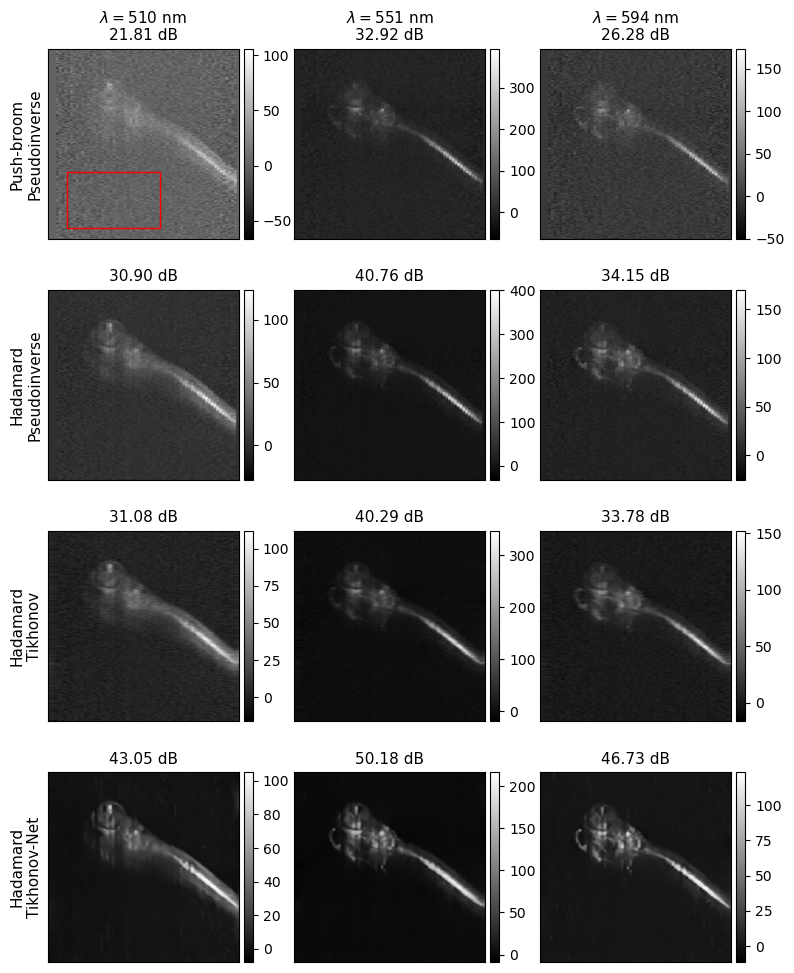

In [24]:
#%% Main plot with PSNR comparison
from matplotlib.patches import Rectangle
from matplotlib.patches import Rectangle
import numpy as np
c_step = 5
lambda_central_list = 510, 551, 594  # Central channel in nanometer
lambda_all = np.linspace(500, 608, 512)

save_folder = 'Reconstruction/hypercube'

fs = 11 # font size

x_noise = [330, 480]
y_noise = [50, 300]

psnr_had = np.zeros(len(lambda_central_list))
psnr_can = np.zeros(len(lambda_central_list))
psnr_had_tikhonov = np.zeros(len(lambda_central_list))
psnr_had_tikhonet = np.zeros(len(lambda_central_list))

f, ax = plt.subplots(4,3, figsize=(9,12))

for i_lambda, lambda_central in enumerate(lambda_central_list):
    
    # pushbroom / canonical
    save_filename = f'can_{lambda_central}_{N}x{N}.npy'
    rec = np.load(Path(data_folder+save_folder) / save_filename)
    psnr_can[i_lambda] = psnr(rec, x_noise, y_noise, False)
  
    im = ax[0,i_lambda].imshow(rec, cmap="gray")
    ax[0,i_lambda].set_title(f'{psnr_can[i_lambda]:.2f} dB', fontsize=fs)
    add_colorbar(im, 'right')
    
    # Hadamard pinv
    save_filename = f'had_{lambda_central}_{N}x{N}.npy'
    rec = np.load(Path(data_folder+save_folder) / save_filename)
    psnr_had[i_lambda] = psnr(rec, x_noise, y_noise, False)
    
    im = ax[1,i_lambda].imshow(rec, cmap="gray")
    ax[1,i_lambda].set_title(f'{psnr_had[i_lambda]:.2f} dB', fontsize=fs)
    add_colorbar(im, 'right')
    
    # Hadamard TiknoNet
    save_filename = f'had_tikhonov_{lambda_central}_{N}x{N}.npy'
    rec = np.load(Path(data_folder+save_folder) / save_filename)
    psnr_had_tikhonov[i_lambda] = psnr(rec, x_noise, y_noise, False)
    
    im = ax[2,i_lambda].imshow(rec, cmap="gray")
    ax[2,i_lambda].set_title(f'{psnr_had_tikhonov[i_lambda]:.2f} dB', fontsize=fs)
    add_colorbar(im, 'right')
    
    # Hadamard TiknoNet
    save_filename = f'had_tikhonet_{lambda_central}_{N}x{N}.npy'
    rec = np.load(Path(data_folder+save_folder) / save_filename)
    psnr_had_tikhonet[i_lambda] = psnr(rec, x_noise, y_noise, False)
    
    im = ax[3,i_lambda].imshow(rec, cmap="gray")
    ax[3,i_lambda].set_title(f'{psnr_had_tikhonet[i_lambda]:.2f} dB', fontsize=fs)
    add_colorbar(im, 'right')
    
    for j in range(4):
        ax[j,i_lambda].set_xticks([])
        ax[j,i_lambda].set_yticks([]) 
    
# Column labels    
method_list = ("Push-broom\nPseudoinverse", 
                "Hadamard\nPseudoinverse", 
                "Hadamard\nTikhonov", 
                "Hadamard\nTikhonov-Net")
for j in range(4):
    ax[j,0].set_ylabel(method_list[j], fontsize=fs)
    
# Row labels    
for i in range(len(lambda_central_list)):
    ax[0,i].set_title(
        fr"$\lambda = {lambda_central_list[i]}$ nm"+'\n'+ax[0,i].get_title(),
        fontsize=fs)

# SNR region    
ax[0,0].add_patch(Rectangle(
    (y_noise[0], x_noise[0]), y_noise[1]-y_noise[0]+1, x_noise[1]-x_noise[0]+1, 
    linewidth=1, edgecolor='r', facecolor='none')
    )

plt.savefig('figure_3.pdf', bbox_inches='tight', dpi=dpi_fig)


with np.printoptions(precision=1, suppress=True):
    print(psnr_had-psnr_can)
    print(psnr_had_tikhonov-psnr_had)
    print(psnr_had_tikhonet-psnr_had)